# Final Project Supervised Learning: Regression

## Data Summary

In [80]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/boston-housing-clean-dataset/boston_housing_clean.pickle


In [81]:
import pickle
with open("/kaggle/input/boston-housing-clean-dataset/boston_housing_clean.pickle","rb") as file:
    boston=pickle.load(file)

### Data Description

The dataset used is the Boston House Prices dataset, which includes 506 instances and 13 numeric/categorical attributes. The target variable is MEDV (Median value of owner-occupied homes).

In [82]:
boston.keys()

dict_keys(['dataframe', 'description'])

In [83]:
boston_data=boston["dataframe"]
boston_description=boston["description"]

In [84]:
boston_data.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1.0,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2.0,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2.0,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3.0,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3.0,222.0,18.7,396.90,5.33,36.2


In [85]:
boston_data.describe()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
count,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,3.593761,11.363636,11.136779,0.069170,0.554695,6.284634,68.574901,3.795043,9.549407,408.237154,18.455534,356.674032,12.653063,22.532806
std,8.596783,23.322453,6.860353,0.253994,0.115878,0.702617,28.148861,2.105710,8.707259,168.537116,2.164946,91.294864,7.141062,9.197104
min,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,0.320000,1.730000,5.000000
25%,0.082045,0.000000,5.190000,0.000000,0.449000,5.885500,45.025000,2.100175,4.000000,279.000000,17.400000,375.377500,6.950000,17.025000
50%,0.256510,0.000000,9.690000,0.000000,0.538000,6.208500,77.500000,3.207450,5.000000,330.000000,19.050000,391.440000,11.360000,21.200000
75%,3.647423,12.500000,18.100000,0.000000,0.624000,6.623500,94.075000,5.188425,24.000000,666.000000,20.200000,396.225000,16.955000,25.000000
max,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,396.900000,37.970000,50.000000


In [86]:
print(boston_description)

Boston House Prices dataset

Notes
------
Data Set Characteristics:  

    :Number of Instances: 506 

    :Number of Attributes: 13 numeric/categorical predictive
    
    :Median Value (attribute 14) is usually the target

    :Attribute Information (in order):
        - CRIM     per capita crime rate by town
        - ZN       proportion of residential land zoned for lots over 25,000 sq.ft.
        - INDUS    proportion of non-retail business acres per town
        - CHAS     Charles River dummy variable (= 1 if tract bounds river; 0 otherwise)
        - NOX      nitric oxides concentration (parts per 10 million)
        - RM       average number of rooms per dwelling
        - AGE      proportion of owner-occupied units built prior to 1940
        - DIS      weighted distances to five Boston employment centres
        - RAD      index of accessibility to radial highways
        - TAX      full-value property-tax rate per $10,000
        - PTRATIO  pupil-teacher ratio by town
      

### Features and Target Variable

In [87]:
X=boston_data.drop("MEDV",axis=1)
y=boston_data["MEDV"]

In [88]:
X

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1.0,296.0,15.3,396.90,4.98
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2.0,242.0,17.8,396.90,9.14
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2.0,242.0,17.8,392.83,4.03
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3.0,222.0,18.7,394.63,2.94
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3.0,222.0,18.7,396.90,5.33
...,...,...,...,...,...,...,...,...,...,...,...,...,...
501,0.06263,0.0,11.93,0.0,0.573,6.593,69.1,2.4786,1.0,273.0,21.0,391.99,9.67
502,0.04527,0.0,11.93,0.0,0.573,6.120,76.7,2.2875,1.0,273.0,21.0,396.90,9.08
503,0.06076,0.0,11.93,0.0,0.573,6.976,91.0,2.1675,1.0,273.0,21.0,396.90,5.64
504,0.10959,0.0,11.93,0.0,0.573,6.794,89.3,2.3889,1.0,273.0,21.0,393.45,6.48


In [89]:
print(y)

0      24.0
1      21.6
2      34.7
3      33.4
4      36.2
       ... 
501    22.4
502    20.6
503    23.9
504    22.0
505    11.9
Name: MEDV, Length: 506, dtype: float64


## Objective of the Analysis
The main objective of this project is to optimize the Bias-Variance Tradeoff by implementing L1(Lasso) and L2(Ridge) Regularization, and validating using Grid Search Cross Validation and building efficient Pipelines to run each model.

* Train-Test Split: Separate data to ensure valid evaluation.
* Polynomial Transformation: Create non-linear features to capture complex trends.
* Standard Scaling: Normalize all features (including polynomials) for fair regularization.
* Baseline Model: Run a standard Linear Regression to show why the model fails without a penalty.
* Regularization Analysis: Apply Lasso and Ridge to the scaled data to stabilize the model.
* Hyperparameter Tuning: Use GridSearchCV to find the best Degree and Alpha simultaneously.
* Final Evaluation: Pick the best model and report $R^2$ and RMSE.

In [90]:
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
import matplotlib.pyplot as plt
import seaborn as sns

### Test Train Split

We partitioned the dataset using a 70:30 ratio (````test_size=0.3````) to balance model training with rigorous evaluation. The training set (70%) provides enough data for the model to learn, while the test set (30%) acts as unseen data to provide an unbiased estimate of the model's true accuracy.
We used ````random_state=42```` to ensure the split is reproducible, meaning the data is shuffled the exact same way every time the code is run for consistent results.

In [91]:
X_train, X_test, y_train, y_test=train_test_split(X,y,test_size=0.3,random_state=42)

## Overfit Baseline

### Linear Regression

Firstly, we fit the scaled data to a standard linear regression model with polynomial features using a Pipeline and validate it with GridSearchCV.

In [92]:
scores={}
s=StandardScaler()
pf=PolynomialFeatures()
lr=LinearRegression()
estimator_lr=Pipeline([("polynomial_features",pf),
                    ("scaler",s),
                    ("linear_regression",lr),
                    ])
params={"polynomial_features__degree":[1,2,3,4]}
grid=GridSearchCV(estimator_lr,params,cv=5)
grid=grid.fit(X_train,y_train)
y_pred_lr=grid.predict(X_test)
score=r2_score(y_test,y_pred_lr)
scores["Linear Regression"]=score

In [93]:
grid.best_params_

{'polynomial_features__degree': 2}

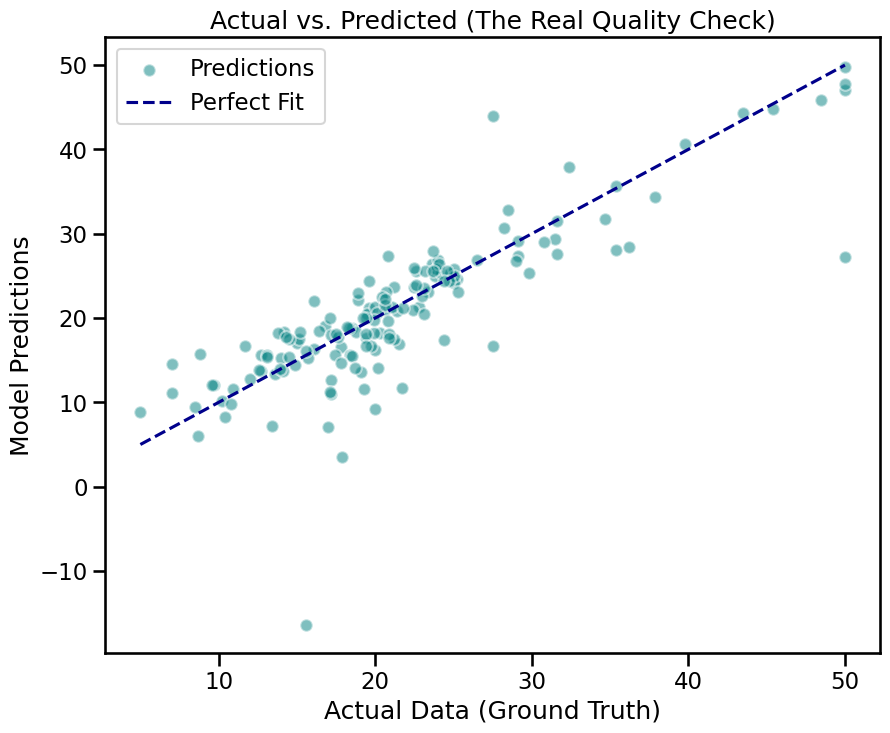

In [94]:
plt.figure(figsize=(10,8))
sns.set_context("talk")

plt.scatter(y_test, y_pred_lr, alpha=0.5, color='teal', edgecolors='white', label="Predictions")

line_coords = [y_test.min(), y_test.max()]
plt.plot(line_coords, line_coords, color='darkblue', linestyle='--', label='Perfect Fit')

plt.title("Actual vs. Predicted (The Real Quality Check)")
plt.xlabel("Actual Data (Ground Truth)")
plt.ylabel("Model Predictions")
plt.legend()
plt.show()

In [115]:
rmse={}
mse_lr=mean_squared_error(y_test,y_pred_lr)
rmse_lr=np.sqrt(mse_lr)
rmse["Linear Regression"]=rmse_lr
print(rmse_lr)

4.963436333270758


Our results show that even with a Degree 2 polynomial, the model has high bias and an RMSE of 4.96.

We observe a tradeoff between Bias and Variance. The standard linear regression model is underfitting because it has high bias and low variance. To balance the two, we will fit the our data to L1 and L2 regularization. 

## Regularization Analysis

### Ridge Regression

In [96]:
ridge=Ridge()
estimator_rr=Pipeline([("polynomial_features",pf),
                    ("scaler",s),
                    ("ridge_regression",ridge),
                    ])
params={"polynomial_features__degree":[1,2,3,4],
        "ridge_regression__alpha":np.geomspace(4,20,30)}
grid_ridge=GridSearchCV(estimator_rr,params,cv=5)
grid_ridge=grid_ridge.fit(X_train,y_train)
y_pred_rr=grid_ridge.predict(X_test)
score=r2_score(y_test,y_pred_rr)
scores["Ridge Regression"]=score

To improve our model, we implemented a Ridge (L2) Regression using a Pipeline and GridSearchCV. We searched across polynomial degrees 1–4 and used a geometric space for Alpha to find the most efficient penalty.

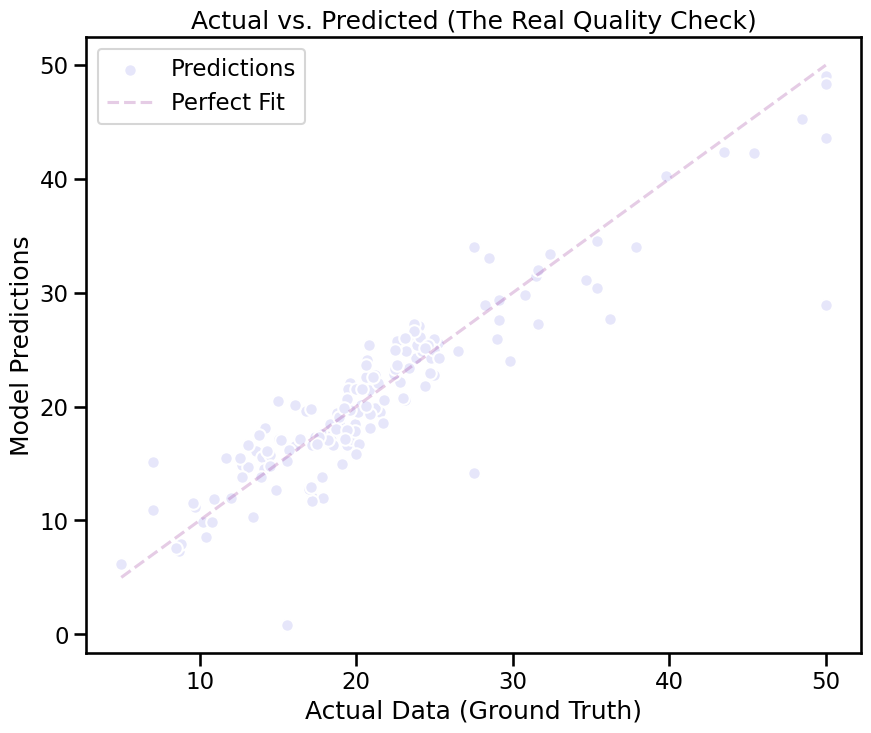

In [97]:
plt.figure(figsize=(10,8))
sns.set_context("talk")

plt.scatter(y_test, y_pred_rr, color='lavender', edgecolors='white', label="Predictions")

line_coords = [y_test.min(), y_test.max()]
plt.plot(line_coords, line_coords, alpha=0.2, color='purple', linestyle='--', label='Perfect Fit')

plt.title("Actual vs. Predicted (The Real Quality Check)")
plt.xlabel("Actual Data (Ground Truth)")
plt.ylabel("Model Predictions")
plt.legend()
plt.show()

The scatter plot demonstrates the model's high accuracy, with most predictions aligning closely with the "Perfect Fit" line. By switching from a standard linear approach to optimized Ridge regression, we achieved a significant performance boost.

In [98]:
mse_rr=mean_squared_error(y_test,y_pred_rr)
rmse_rr=np.sqrt(mse_rr)
rmse["Ridge Regression"]=rmse_rr
print(rmse_rr)

3.5025191445467545


In [99]:
grid_ridge.best_params_

{'polynomial_features__degree': 3, 'ridge_regression__alpha': np.float64(4.0)}

The grid search identified Degree 3 and Alpha 4.0 as the optimal hyperparameters.

### Lasso Regression

In [100]:
#suppressing convergence warnings
import warnings 
from sklearn.exceptions import ConvergenceWarning
warnings.filterwarnings("ignore",category=ConvergenceWarning)
alphas = np.geomspace(0.001, 10, num=10)
lasso=Lasso(max_iter=20000)
estimator_lassor=Pipeline([("polynomial_features",pf),
                    ("scaler",s),
                    ("lasso_regression",lasso)])
params={"polynomial_features__degree":[1,2,3,4],
        "lasso_regression__alpha":alphas}
grid_lasso=GridSearchCV(estimator_lassor,params,cv=5)
grid_lasso=grid_lasso.fit(X_train,y_train)
y_pred_lassor=grid_lasso.predict(X_test)
score=r2_score(y_test,y_pred_lassor)
scores["Lasso Regression"]=score

Next, we implemented Lasso (L1) Regression using a similar Pipeline and GridSearchCV. Lasso is unique because it performs feature selection by shrinking the coefficients of less important features to exactly zero.

We suppressed convergence warnings because the Lasso algorithm requires more iterations to find a solution when dealing with complex, high-degree polynomial features.

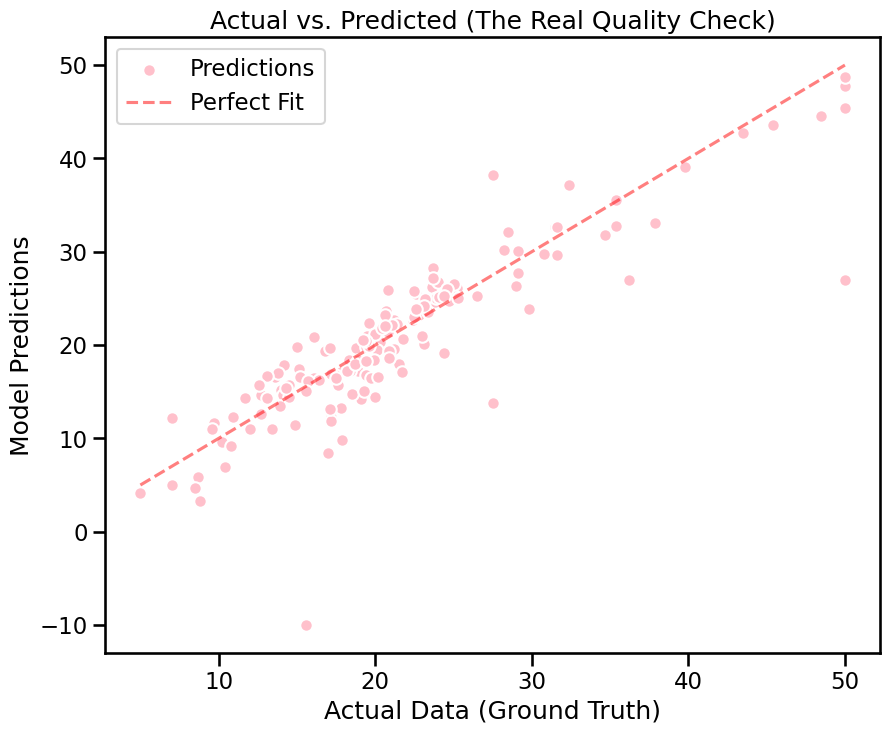

In [101]:
plt.figure(figsize=(10,8))
sns.set_context("talk")

plt.scatter(y_test, y_pred_lassor, color='pink', edgecolors='white', label="Predictions")

line_coords = [y_test.min(), y_test.max()]
plt.plot(line_coords, line_coords, alpha=0.5, color='red', linestyle='--', label='Perfect Fit')

plt.title("Actual vs. Predicted (The Real Quality Check)")
plt.xlabel("Actual Data (Ground Truth)")
plt.ylabel("Model Predictions")
plt.legend()
plt.show()

The scatter plot shows that the predictions are reasonably accurate, but there is more spread around the "Perfect Fit" line compared to Ridge. This suggests that Lasso's feature elimination may have discarded some useful information, leading to a slightly higher error than the Ridge model's smoother regularization.

In [102]:
mse_lassor=mean_squared_error(y_test,y_pred_lassor)
rmse_lassor=np.sqrt(mse_lassor)
rmse["Lasso Regression"]=rmse_lassor
print(rmse_lassor)

4.15310404156189


While Lasso improved significantly over the baseline Linear Regression, it did not perform as well as the Ridge model.

## Choosing Best Model

In [103]:
results_df = pd.DataFrame({'R2 Score': scores, 'RMSE': rmse})
results_df

,R2 Score,RMSE
Linear Regression,0.669378,4.963436
Ridge Regression,0.835363,3.502519
Lasso Regression,0.768520,4.153104


In [111]:
all = {"Linear Regression": grid,
       "Lasso Regression": grid_lasso,
       "Ridge Regression": grid_ridge}
best = max(scores, key=scores.get)
best_model = all[best].best_estimator_
print("The best fit is:",best)
print("Best Parameters:", all[best].best_params_)

The best fit is: Ridge Regression
Best Parameters: {'polynomial_features__degree': 3, 'ridge_regression__alpha': np.float64(4.0)}


Ridge Regression is the best model because it optimizes the Bias-Variance Tradeoff. It avoids the high bias of Linear Regression and the aggressive feature elimination of Lasso. By using L2 regularization to shrink coefficients rather than zeroing them out, it allowed for a complex 3rd-degree polynomial fit with the lowest error (RMSE 3.50).

## Limitations

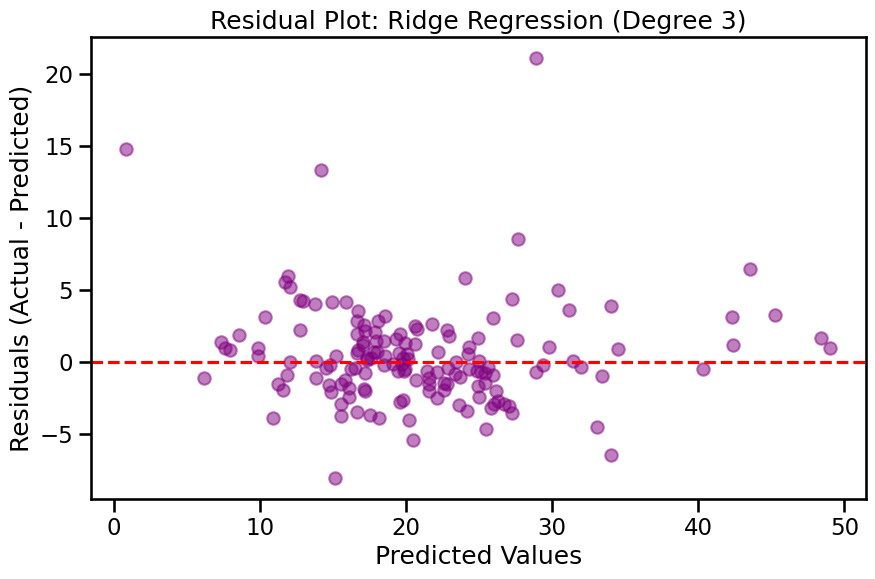

In [112]:
residuals = y_test - y_pred_rr

plt.figure(figsize=(10, 6))
plt.scatter(y_pred_rr, residuals, alpha=0.5, color='purple')
plt.axhline(0, color='red', linestyle='--')
plt.title('Residual Plot: Ridge Regression (Degree 3)')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals (Actual - Predicted)')
plt.show()

The random scatter of residuals confirms a strong fit, but the model remains limited by the existing features and cannot predict extreme market outliers.

## Final Evaluation & Conclusion

In [114]:
print("-"*35,"Final Report","-"*35)
print("Best Model:",best)
print("RMSE of Ridge Regression:",rmse_rr)
print("R2 Score of Ridge Regression:",scores['Ridge Regression'])
print("Best Parameters:",grid_ridge.best_params_)

----------------------------------- Final Report -----------------------------------
Best Model: Ridge Regression
RMSE of Ridge Regression: 3.5025191445467545
R2 Score of Ridge Regression: 0.8353626263353523
Best Parameters: {'polynomial_features__degree': 3, 'ridge_regression__alpha': np.float64(4.0)}


* Best model is Ridge Regression.
* The best_params_ confirms that a 3rd-degree polynomial combined with Alpha 4.0 provided the most stable predictions.
* The $R^2$ of 0.835 means the model explains 83.5% of the variance in house prices.
* 3.50 RMSE means that the model is missing the actual targets by an average error of 3.50.